**Victoria Maslova. July 2021**

Introduction

For this competiton, we are given a data set of 1460 homes, each with a few dozen features of types: float, integer, and categorical. We are tasked with building a regression model to estimate a home's sale price. Total number of attributes equals 81, of which 36 is quantitative, 43 categorical + Id and SalePrice.

What I will show you on this notebook?

Understanding the data
Exploratory Data Analysis
Data Preprocessing
PCA Trial
GBM and XGBoost Models
Submission

In [1]:
##### IMPORT LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew
from scipy.special import boxcox1p
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")
traindf = train.copy()
testdf = test.copy()

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
trainshape = ("Train Data:",train.shape[0],"obs, and", train.shape[1], "features" )
print("\033[95m {}\033[00m" .format(trainshape))
testshape = ("Test Data:",test.shape[0],"obs, and", test.shape[1], "features" )
print("\033[95m {}\033[00m" .format(testshape))

 ('Train Data:', 1460, 'obs, and', 81, 'features')
 ('Test Data:', 1459, 'obs, and', 80, 'features')


In [6]:
# save id 
train_id = train["Id"]
test_id = test["Id"]

# drop id
train.drop("Id" , axis = 1 , inplace = True)
test.drop("Id" , axis = 1 , inplace = True)

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


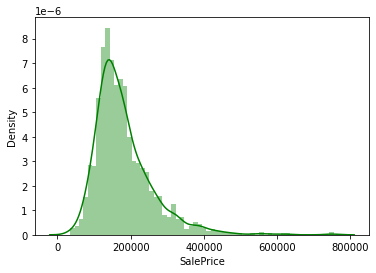

In [8]:
# Focus Target Variable

sns.distplot(train["SalePrice"] , color = "g", bins = 60 , hist_kws={"alpha": 0.4});

As you can see above, the target variable SalePrice is not distributed normally.

This can reduce the performance of the ML regression models because some of them assume normal distribution.

Therfore we need to log transform.

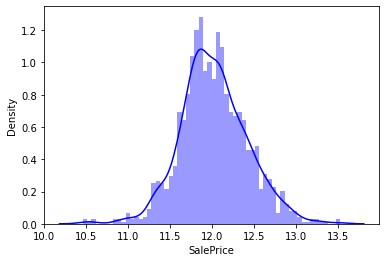

In [9]:
sns.distplot(np.log1p(train["SalePrice"]) , color = "b", bins = 60 , hist_kws={"alpha": 0.4});

Let's create the best 8 correlation with heatmap.

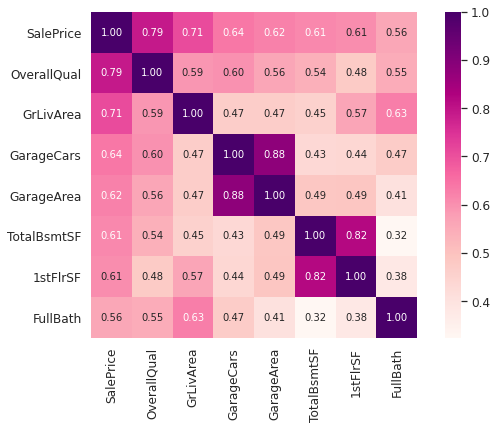

In [10]:
corrmatrix = train.corr()
plt.figure(figsize = (10,6))
columnss = corrmatrix.nlargest(8, "SalePrice")["SalePrice"].index
cm = np.corrcoef(train[columnss].values.T)
sns.set(font_scale = 1.1)
hm = sns.heatmap(cm, cbar = True, annot = True, square = True, cmap = "RdPu" ,  fmt = ".2f", annot_kws = {"size": 10},
                 yticklabels = columnss.values, xticklabels = columnss.values)
plt.show()

Now let's look at the distribution of the variable with the 3 highest correlations.

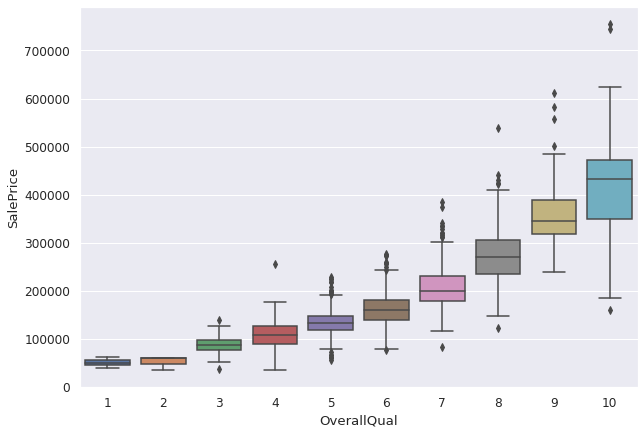

In [11]:
f, ax = plt.subplots(figsize = (10, 7))
sns.boxplot(x = "OverallQual", y = "SalePrice", data = train);

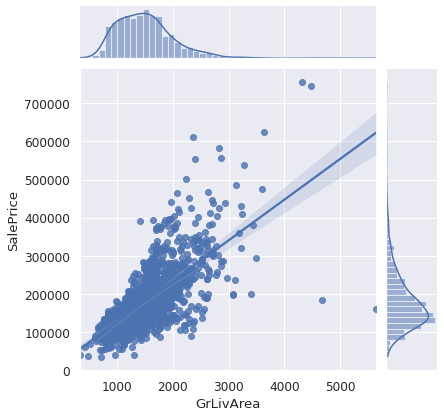

In [12]:
sns.jointplot(x = train["GrLivArea"], y = train["SalePrice"], kind = "reg");

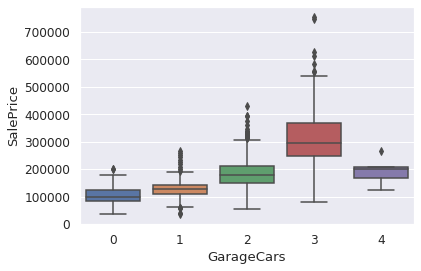

In [13]:
sns.boxplot(x = train["GarageCars"], y = train["SalePrice"]);

Outliers

Can you see two points at the bottom right on GrLivArea. Yes ! It's outliers !

Car garages result in less Sale Price? That doesn't make much sense.

We need to remove outliers.

In [14]:
train = train.drop(train[(train["GrLivArea"] > 4000) 
                         & (train["SalePrice"] < 200000)].index).reset_index(drop = True)
train = train.drop(train[(train["GarageCars"] > 3) 
                         & (train["SalePrice"] < 300000)].index).reset_index(drop = True)

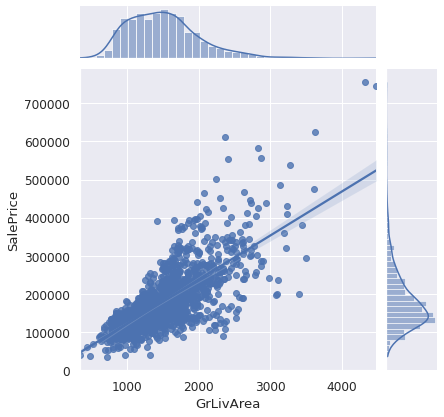

In [15]:
sns.jointplot(x = train["GrLivArea"], y = train["SalePrice"], kind = "reg");

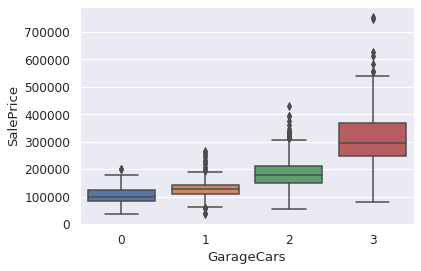

In [16]:
sns.boxplot(x = train["GarageCars"], y = train["SalePrice"]);

Next step is to concanete train and test data for some cleaning operations.

In [17]:
df = pd.concat((train, test)).reset_index(drop = True)
df.drop(["SalePrice"], axis = 1, inplace = True)
df.shape

(2912, 79)

In [18]:
##Focus missing values

df.isna().sum().nlargest(35)

PoolQC          2903
MiscFeature     2807
Alley           2715
Fence           2342
FireplaceQu     1417
LotFrontage      485
GarageYrBlt      159
GarageFinish     159
GarageQual       159
GarageCond       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrType        24
MasVnrArea        23
MSZoning           4
Utilities          2
BsmtFullBath       2
BsmtHalfBath       2
Functional         2
Exterior1st        1
Exterior2nd        1
BsmtFinSF1         1
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
KitchenQual        1
GarageCars         1
GarageArea         1
SaleType           1
MSSubClass         0
dtype: int64

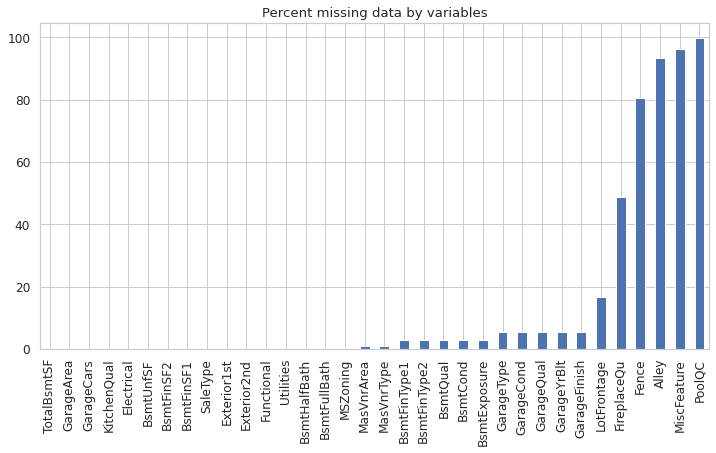

In [19]:
sns.set_style("whitegrid")
f , ax = plt.subplots(figsize = (12, 6))
miss = round(df.isnull().mean()*100,2)
miss = miss[miss > 0]
miss.sort_values(inplace = True)
miss.plot.bar(color = "b")
ax.set(title="Percent missing data by variables");

**Filling missing values**

For a few columns there is lots of NaN entries.

However, reading the data description we find this is not missing data:

For PoolQC, NaN is not missing data but means no pool, likewise for Fence, FireplaceQu etc.

Now, lets filling NA values 

In [20]:
some_miss_columns = ["PoolQC","MiscFeature","Alley","Fence","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond",
                  "BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","MasVnrType","MSSubClass"]

for i in some_miss_columns :
        df[i].fillna("None" , inplace = True)

In [21]:
df["Functional"] = df["Functional"].fillna("Typ")

In [22]:
some_miss_columns2 = ["MSZoning", "BsmtFullBath", "BsmtHalfBath", "Utilities","MSZoning",
                      "Electrical", "KitchenQual", "SaleType","Exterior1st", "Exterior2nd","MasVnrArea"]
for i in some_miss_columns2:
    df[i].fillna(df[i].mode()[0], inplace = True)

In [23]:
some_miss_columns3 = ["GarageYrBlt", "GarageArea", "GarageCars","BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","TotalBsmtSF"]
for i in some_miss_columns3 :
    df[i] = df[i].fillna(0)

In [24]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [25]:
##We've filled out all the missing data. Let's control.
df.isna().sum().nlargest(3)

MSSubClass     0
MSZoning       0
LotFrontage    0
dtype: int64

In [26]:
## Transform for some variables
Nm = ["MSSubClass","MoSold","YrSold"]
for col in Nm:
    df[col] = df[col].astype(str)

Label Encoder

Convert this kind of categorical text data into model-understandable numerical data, we use the Label Encoder class.

In [27]:
label = LabelEncoder()
encodecolumns = ("FireplaceQu","BsmtQual","BsmtCond","ExterQual","ExterCond","HeatingQC","GarageQual",
                "GarageCond","PoolQC","KitchenQual","BsmtFinType1","BsmtFinType2","Functional","Fence",
                "BsmtExposure","GarageFinish","LandSlope","LotShape","PavedDrive","Street","Alley",
                "CentralAir","MSSubClass","OverallCond","YrSold","MoSold")
for i in encodecolumns :
    label.fit(list(df[i].values))
    df[i] = label.transform(list(df[i].values))

Log Transform for SalePrice

Apply logarithmic transformation to our target variable.Because ML models work better with normal distribution.

In [28]:
train["SalePrice"] = np.log1p(train["SalePrice"])
y = train.SalePrice.values
y[:5]

array([12.24769912, 12.10901644, 12.31717117, 11.84940484, 12.4292202 ])

Fixing "Skewed" features

Fix all of the skewed data to be more normal so that our models will be more accurate when making predictions.

In [29]:
numeric = df.dtypes[df.dtypes != "object"].index
skewed_var = df[numeric].apply(lambda x: skew(x.dropna())).sort_values(ascending = False)
skewness = pd.DataFrame({"Skewed Features" :skewed_var})
skewness.head()

,Skewed Features
MiscVal,21.920854
PoolArea,17.673354
LotArea,13.150188
LowQualFinSF,12.073977
3SsnPorch,11.362112


Apply a Box Cox transformation


A Box Cox transformation is a transformation of a non-normal dependent variables into a normal shape. Normality is an important assumption for many statistical techniques; if your data isn’t normal, applying a Box-Cox means that you are able to run a broader number of tests.


In [30]:
skewness = skewness[abs(skewness) > 0.75]
skewed_var2 = skewness.index
for i in skewed_var2:
    df[i] = boxcox1p(df[i], 0.15)
    df[i] += 1

Next step is dummy variables !

In statistics and econometrics, particularly in regression analysis, a dummy variable is one that takes only the value 0 or 1 to indicate the absence or presence of some categorical effect that may be expected to shift the outcome.

In [31]:
df = pd.get_dummies(df)
df.head()

,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,3.885846,6.831328,20.212182,1.730463,1.730463,2.540963,1.0,3.440268,2.820334,15.187527,...,0,0,0,1,0,0,0,0,1,0
1,3.055642,7.221214,20.712205,1.730463,1.730463,2.540963,1.0,3.259674,3.440268,15.145138,...,0,0,0,1,0,0,0,0,1,0
2,3.885846,6.914940,21.347241,1.730463,1.730463,1.000000,1.0,3.440268,2.820334,15.184404,...,0,0,0,1,0,0,0,0,1,0
3,4.011340,6.684507,20.691553,1.730463,1.730463,1.000000,1.0,3.440268,2.820334,15.047529,...,0,0,0,1,1,0,0,0,0,0
4,3.885846,7.314735,22.325160,1.730463,1.730463,1.000000,1.0,3.602594,2.820334,15.182841,...,0,0,0,1,0,0,0,0,1,0


In [32]:
X_train = df[:train.shape[0]]
X_test = df[train.shape[0]:]

I applied a PCA.

PCA (Principal component analysis)

PCA is used in exploratory data analysis and for making predictive models. It is commonly used for dimensionality reduction by projecting each data point onto only the first few principal components to obtain lower-dimensional data while preserving as much of the data's variation as possible. The first principal component can equivalently be defined as a direction that maximizes the variance of the projected data. Lets try it.

Note : First standardize the data before using PCA.

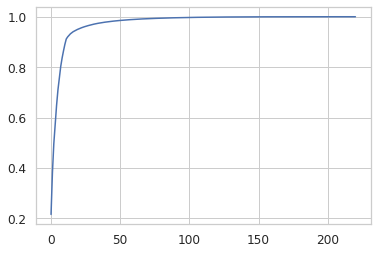

In [33]:
dff = df.copy()
##df_standardize = StandardScaler().fit_transform(dff)
##I didn't standardize it again because the data is already close to the standard.
pca = PCA()
pca_fit = pca.fit_transform(dff)
pca = PCA().fit(dff)
plt.plot(np.cumsum(pca.explained_variance_ratio_));

With about 30 variables, we can explain 90% of the variance in the dataset.How do we do that ?

In [34]:
pca = PCA(n_components = 30)
pca_fit = pca.fit_transform(dff)
pca_df = pd.DataFrame(data = pca_fit)
pca_df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,1.310874,-7.644388,-3.190557,-6.130242,-1.231003,1.802676,0.149904,1.802519,-0.081996,-1.064012,...,0.017595,0.696868,-0.548369,0.058677,0.334831,-0.301677,-0.253461,0.126670,0.164188,-0.136961
1,-6.792759,0.934007,-1.220512,5.201498,1.143536,-3.922942,-3.233540,0.318292,-1.110764,-0.084848,...,0.253282,0.448805,0.091689,-0.366063,0.536240,1.365346,-0.299259,0.304542,-0.845534,0.906373
2,2.258800,-7.309320,-1.561536,-5.963476,-1.504997,0.673385,-0.047281,0.567739,-0.445352,-0.352704,...,-0.052005,0.245649,0.114749,0.148739,0.584641,-0.631146,-0.305569,-0.229323,0.157781,-0.220837
3,5.713698,-1.996913,-4.386689,-2.343667,-4.081766,-3.358525,-0.259982,-2.570543,6.024252,-1.719936,...,0.128986,-1.476937,0.610440,-0.338842,0.894302,0.790523,1.121572,-0.013111,-0.322748,-0.458582
4,0.639671,-12.038284,0.643347,-0.953167,2.368347,0.493921,-0.421904,0.242407,0.724364,-0.126743,...,-0.269940,-0.105973,0.322756,0.403896,0.927206,-0.267478,-0.148606,0.176589,0.142683,0.371124


**Now, we will predict models ! Firstly start Cross-validation with k-folds**

In [35]:
n_folds = 5

def rmsle_cv(model):
    kf = KFold(n_folds, shuffle = True, random_state = 42).get_n_splits(X_train.values)
    rmse = np.sqrt(-cross_val_score(model, X_train.values, y, scoring = "neg_mean_squared_error", cv = kf))
    return(rmse)

In [36]:
model_xgb = xgb.XGBRegressor(colsample_bytree = 0.2, gamma = 0.0 ,
                             learning_rate = 0.05, max_depth = 6, 
                             min_child_weight = 1.5, n_estimators = 7200,
                             reg_alpha = 0.9, reg_lambda = 0.6,
                             subsample = 0.2,seed = 42,
                             random_state = 7)

model_gbm = GradientBoostingRegressor(n_estimators = 3000, learning_rate = 0.05,
                                   max_depth = 4, max_features = "sqrt",
                                   min_samples_leaf = 15, min_samples_split = 10, 
                                   loss = "huber", random_state = 5)

In [37]:
score = rmsle_cv(model_xgb)
print("XGBoost score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))
score = rmsle_cv(model_gbm)
print("Gradient Boosting score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

XGBoost score: 0.1193 (0.0049)

Gradient Boosting score: 0.1155 (0.0067)



In [38]:
## we need this func

def rmsle(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

**XGBoost**

In [39]:
model_xgb.fit(X_train, y)
xgb_train_pred = model_xgb.predict(X_train)
xgb_pred = np.expm1(model_xgb.predict(X_test))
print(rmsle(y, xgb_train_pred))

0.04271630532453864


In [40]:
xgb_pred[:5]

array([127030.77, 162863.4 , 187234.12, 195402.38, 187380.44],
      dtype=float32)

GBM (Gradient Boosting Machines)

In [41]:
model_gbm.fit(X_train, y)
gbm_train_pred = model_gbm.predict(X_train)
gbm_pred = np.expm1(model_gbm.predict(X_test.values))
print(rmsle(y, gbm_train_pred))

0.05041437359684839


In [42]:
gbm_pred[:5]

array([120735.81992324, 156981.67681747, 194467.06024408, 196102.90381639,
       189486.60416949])

**SUBMISSION**

In [43]:
best = (0.5 * xgb_pred ) + (0.5 * gbm_pred)

In [44]:
submission = pd.DataFrame({"Id": test_id, "SalePrice": best})
submission.head(5)

,Id,SalePrice
0,1461,123883.296680
1,1462,159922.541534
2,1463,190850.592622
3,1464,195752.639408
4,1465,188433.520835


In [45]:
submission.to_csv("submission.csv", index = False)